In [ ]:
# Install dependencies
!pip install -U transformers accelerate bitsandbytes pillow numpy pandas scikit-image opencv-python tqdm matplotlib
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-n7hpu2q3
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-n7hpu2q3
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=9c22b6eb4e5e7f3edaf7e9c843b437353b9dbe96ba2ac63d7166a56fdc8c5140
  Stored in directory: /tmp/pip-ephem-wheel-cache-3c5ew9ih/wheels/29/82/ff/04e2be9805a1cb48bec0b85b5a6da6b63f647645750a0e42d4
Successfully built segment_anything


In [ ]:
!git clone https://github.com/bowang-lab/MedSAM.git

Cloning into 'MedSAM'...
remote: Enumerating objects: 967, done.
remote: Total 967 (delta 0), reused 0 (delta 0), pack-reused 967 (from 1)
Receiving objects: 100% (967/967), 62.91 MiB | 12.56 MiB/s, done.
Resolving deltas: 100% (475/475), done.


In [ ]:
%cd MedSAM

/content/MedSAM


In [ ]:
!pip install -e .

Obtaining file:///content/MedSAM
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.3 MB/s eta 0:00:00
  Running setup.py develop for medsam


In [ ]:
%cd ..

!unzip DS_processed.zip -d datasets

/content
Archive:  DS_processed.zip
   creating: datasets/DS_processed/CVC-ClinicDB/
   creating: datasets/DS_processed/CVC-ClinicDB/test/
   creating: datasets/DS_processed/CVC-ClinicDB/test/images/
  inflating: datasets/DS_processed/CVC-ClinicDB/test/images/0.jpg  
  inflating: datasets/DS_processed/CVC-ClinicDB/test/images/1.jpg  
  inflating: datasets/DS_processed/CVC-ClinicDB/test/images/10.jpg  
  inflating: datasets/DS_processed/CVC-ClinicDB/test/images/11.jpg  
  inflating: datasets/DS_processed/CVC-ClinicDB/test/images/12.jpg  
  inflating: datasets/DS_processed/CVC-ClinicDB/test/images/13.jpg  
  inflating: datasets/DS_processed/CVC-ClinicDB/test/images/14.jpg  
  inflating: datasets/DS_processed/CVC-ClinicDB/test/images/15.jpg  
  inflating: datasets/DS_processed/CVC-ClinicDB/test/images/16.jpg  
  inflating: datasets/DS_processed/CVC-ClinicDB/test/images/17.jpg  
  inflating: datasets/DS_processed/CVC-ClinicDB/test/images/18.jpg  
  inflating: datasets/DS_processed/CVC-Clin

In [ ]:
!mv datasets/DS_processed/ .

In [ ]:
from huggingface_hub import login
from google.colab import userdata

hf_token = userdata.get("HF_TOKEN")  # or replace with your token string
login(hf_token)
print("HF login done")

HF login done


In [ ]:
DATASETS = {
    "Kvasir-SEG": "/content/Datasets/Kvasir-SEG",
    "CVC-ClinicDB": "/content/Datasets/CVC-ClinicDB",
    "CVC-ColonDB": "/content/Datasets/CVC-ColonDB",
    "ETIS-LaribPolypDB": "/content/Datasets/ETIS-LaribPolypDB",
}

RETRIEVAL_MODEL_ID = "google/medsiglip-448"

OUTPUT_DIR = "/content/global_multidataset_retrieval"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
!pwd

/content


In [ ]:
import os
import gc
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

from transformers import AutoProcessor, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def list_images_recursive(folder):
    folder = Path(folder)
    files = []
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            files.append(str(p))
    return sorted(files)

def open_rgb(path):
    return Image.open(path).convert("RGB")

def get_image_embedding(model, processor, image_path, device):
    img = open_rgb(image_path)
    inputs = processor(images=img, return_tensors="pt").to(device)

    with torch.no_grad():
        out = model.get_image_features(**inputs)

    if isinstance(out, torch.Tensor):
        emb = out.detach().cpu().numpy().squeeze()
    elif hasattr(out, "image_embeds") and out.image_embeds is not None:
        emb = out.image_embeds.detach().cpu().numpy().squeeze()
    elif hasattr(out, "pooler_output") and out.pooler_output is not None:
        emb = out.pooler_output.detach().cpu().numpy().squeeze()
    else:
        emb = out.last_hidden_state[:, 0].detach().cpu().numpy().squeeze()

    emb = emb.astype(np.float32)
    emb = emb / (np.linalg.norm(emb) + 1e-8)
    return emb

In [ ]:
def collect_global_train_index(datasets_dict):
    rows = []

    for dataset_name, dataset_root in datasets_dict.items():
        train_dir = os.path.join(dataset_root, "train", "images")
        image_paths = list_images_recursive(train_dir)

        for img_path in image_paths:
            rows.append({
                "image_path": img_path,
                "image_name": os.path.basename(img_path),
                "dataset": dataset_name,
                "split": "train",
            })

    index_df = pd.DataFrame(rows)
    return index_df

In [ ]:
def build_retrieval_index_from_dataframe(
    index_df,
    model_id="google/medsiglip-448",
    index_csv="/content/retrieval_index.csv",
    embed_npy="/content/retrieval_embeddings.npy",
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)
    print("Index images:", len(index_df))

    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(device).eval()

    rows = []
    embeds = []

    for _, row in tqdm(index_df.iterrows(), total=len(index_df), desc="Indexing train gallery"):
        img_path = row["image_path"]
        try:
            emb = get_image_embedding(model, processor, img_path, device)
            embeds.append(emb)
            rows.append({
                "image_path": img_path,
                "image_name": row["image_name"],
                "dataset": row["dataset"],
                "split": row["split"],
            })
        except Exception as e:
            print(f"Skip {img_path}: {e}")

    if len(embeds) == 0:
        raise ValueError("No embeddings created.")

    embeddings = np.vstack(embeds)
    final_index_df = pd.DataFrame(rows)

    np.save(embed_npy, embeddings)
    final_index_df.to_csv(index_csv, index=False)

    del model, processor
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("Saved:", index_csv, embed_npy)
    return final_index_df, embeddings

In [ ]:
def collect_all_test_queries(datasets_dict):
    rows = []

    for dataset_name, dataset_root in datasets_dict.items():
        test_dir = os.path.join(dataset_root, "test", "images")
        image_paths = list_images_recursive(test_dir)

        for img_path in image_paths:
            rows.append({
                "query_image_path": img_path,
                "query_image_name": os.path.basename(img_path),
                "query_dataset": dataset_name,
                "query_split": "test",
            })

    query_df = pd.DataFrame(rows)
    return query_df

In [ ]:
def retrieve_similar_images_with_loaded_model(
    query_image_path,
    index_df,
    embeddings,
    model,
    processor,
    device,
    top_k=5,
):
    query_emb = get_image_embedding(model, processor, query_image_path, device)
    sims = cosine_similarity([query_emb], embeddings)[0]
    order = np.argsort(sims)[::-1]

    results = []
    rank = 1
    query_abs = os.path.abspath(query_image_path)

    for idx in order:
        candidate_path = index_df.iloc[idx]["image_path"]

        # safety check in case same file somehow appears
        if os.path.abspath(candidate_path) == query_abs:
            continue

        results.append({
            "rank": rank,
            "image_path": candidate_path,
            "image_name": index_df.iloc[idx]["image_name"],
            "dataset": index_df.iloc[idx]["dataset"],
            "split": index_df.iloc[idx]["split"],
            "similarity": float(sims[idx]),
        })
        rank += 1

        if len(results) >= top_k:
            break

    return results

In [ ]:
def run_global_multidataset_protocol(
    datasets_dict,
    model_id="google/medsiglip-448",
    top_k=5,
):
    experiment_dir = os.path.join(OUTPUT_DIR, "protocol_A_global_index")
    os.makedirs(experiment_dir, exist_ok=True)

    index_csv = os.path.join(experiment_dir, "global_train_index.csv")
    embed_npy = os.path.join(experiment_dir, "global_train_embeddings.npy")
    results_csv = os.path.join(experiment_dir, "all_query_results.csv")
    summary_csv = os.path.join(experiment_dir, "dataset_summary.csv")
    source_matrix_csv = os.path.join(experiment_dir, "retrieval_source_matrix.csv")

    # 1) Build global train index
    index_input_df = collect_global_train_index(datasets_dict)
    index_df, embeddings = build_retrieval_index_from_dataframe(
        index_df=index_input_df,
        model_id=model_id,
        index_csv=index_csv,
        embed_npy=embed_npy,
    )

    # 2) Collect all test queries
    query_df = collect_all_test_queries(datasets_dict)
    print("Total test queries:", len(query_df))

    # 3) Load retrieval model once
    device = "cuda" if torch.cuda.is_available() else "cpu"
    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(device).eval()

    # 4) Retrieve for each query
    all_rows = []

    for _, qrow in tqdm(query_df.iterrows(), total=len(query_df), desc="Retrieving for all test queries"):
        query_path = qrow["query_image_path"]
        query_dataset = qrow["query_dataset"]

        retrieved = retrieve_similar_images_with_loaded_model(
            query_image_path=query_path,
            index_df=index_df,
            embeddings=embeddings,
            model=model,
            processor=processor,
            device=device,
            top_k=top_k,
        )

        for item in retrieved:
            all_rows.append({
                "query_dataset": query_dataset,
                "query_image_path": query_path,
                "query_image_name": qrow["query_image_name"],
                "retrieved_rank": item["rank"],
                "retrieved_image_path": item["image_path"],
                "retrieved_image_name": item["image_name"],
                "retrieved_dataset": item["dataset"],
                "retrieved_split": item["split"],
                "similarity": item["similarity"],
                "same_dataset_match": int(query_dataset == item["dataset"]),
            })

    results_df = pd.DataFrame(all_rows)
    results_df.to_csv(results_csv, index=False)
    print("Saved full results:", results_csv)

    # cleanup model
    del model, processor
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # 5) Dataset-level metrics
    summary_rows = []

    for dataset_name in query_df["query_dataset"].unique():
        df_d = results_df[results_df["query_dataset"] == dataset_name].copy()

        # Top-1 same-dataset accuracy
        top1 = df_d[df_d["retrieved_rank"] == 1]
        top1_same_dataset_acc = top1["same_dataset_match"].mean() if len(top1) > 0 else np.nan

        # Top-K same-dataset hit rate:
        # for each query, did ANY of the top-k belong to the same dataset?
        per_query_hit = (
            df_d.groupby("query_image_path")["same_dataset_match"]
            .max()
            .reset_index()
        )
        topk_same_dataset_hit = per_query_hit["same_dataset_match"].mean() if len(per_query_hit) > 0 else np.nan

        summary_rows.append({
            "query_dataset": dataset_name,
            "num_queries": df_d["query_image_path"].nunique(),
            "top1_same_dataset_accuracy": top1_same_dataset_acc,
            f"top{top_k}_same_dataset_hit_rate": topk_same_dataset_hit,
        })

    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(summary_csv, index=False)
    print("Saved summary:", summary_csv)

    # 6) Retrieval source distribution matrix
    source_matrix = (
        results_df.groupby(["query_dataset", "retrieved_dataset"])
        .size()
        .unstack(fill_value=0)
    )
    source_matrix.to_csv(source_matrix_csv)
    print("Saved source matrix:", source_matrix_csv)

    return {
        "index_df": index_df,
        "query_df": query_df,
        "results_df": results_df,
        "summary_df": summary_df,
        "source_matrix": source_matrix,
        "index_csv": index_csv,
        "embed_npy": embed_npy,
        "results_csv": results_csv,
        "summary_csv": summary_csv,
        "source_matrix_csv": source_matrix_csv,
    }

In [ ]:
protocol_a_out = run_global_multidataset_protocol(
    datasets_dict=DATASETS,
    model_id=RETRIEVAL_MODEL_ID,
    top_k=5,
)

Device: cuda
Index images: 1748


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Indexing train gallery: 100%|██████████| 1748/1748 [09:47<00:00,  2.98it/s]


Saved: /content/global_multidataset_retrieval/protocol_A_global_index/global_train_index.csv /content/global_multidataset_retrieval/protocol_A_global_index/global_train_embeddings.npy
Total test queries: 220


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

Retrieving for all test queries: 100%|██████████| 220/220 [01:15<00:00,  2.90it/s]


Saved full results: /content/global_multidataset_retrieval/protocol_A_global_index/all_query_results.csv
Saved summary: /content/global_multidataset_retrieval/protocol_A_global_index/dataset_summary.csv
Saved source matrix: /content/global_multidataset_retrieval/protocol_A_global_index/retrieval_source_matrix.csv


In [ ]:
protocol_a_out["summary_df"]

,query_dataset,num_queries,top1_same_dataset_accuracy,top5_same_dataset_hit_rate
0,Kvasir-SEG,100,0.98,1.0
1,CVC-ClinicDB,62,1.00,1.0
2,CVC-ColonDB,38,1.00,1.0
3,ETIS-LaribPolypDB,20,1.00,1.0


In [ ]:
protocol_a_out["source_matrix"]

retrieved_dataset,CVC-ClinicDB,CVC-ColonDB,ETIS-LaribPolypDB,Kvasir-SEG
query_dataset,,,,
CVC-ClinicDB,308,2,0,0
CVC-ColonDB,9,179,2,0
ETIS-LaribPolypDB,4,2,92,2
Kvasir-SEG,11,1,0,488


In [ ]:
source_matrix = protocol_a_out["source_matrix"]
source_matrix_percent = source_matrix.div(source_matrix.sum(axis=1), axis=0) * 100
source_matrix_percent.round(2)

retrieved_dataset,CVC-ClinicDB,CVC-ColonDB,ETIS-LaribPolypDB,Kvasir-SEG
query_dataset,,,,
CVC-ClinicDB,99.35,0.65,0.00,0.0
CVC-ColonDB,4.74,94.21,1.05,0.0
ETIS-LaribPolypDB,4.00,2.00,92.00,2.0
Kvasir-SEG,2.20,0.20,0.00,97.6


In [ ]:
def plot_source_matrix_heatmap(source_matrix_percent, figsize=(8, 6), save_path=None):
    plt.figure(figsize=figsize)
    plt.imshow(source_matrix_percent.values, aspect="auto")
    plt.colorbar(label="Percentage of retrieved samples")

    plt.xticks(range(len(source_matrix_percent.columns)), source_matrix_percent.columns, rotation=45, ha="right")
    plt.yticks(range(len(source_matrix_percent.index)), source_matrix_percent.index)

    plt.xlabel("Retrieved dataset")
    plt.ylabel("Query dataset")
    plt.title("Retrieval Source Distribution (%)")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

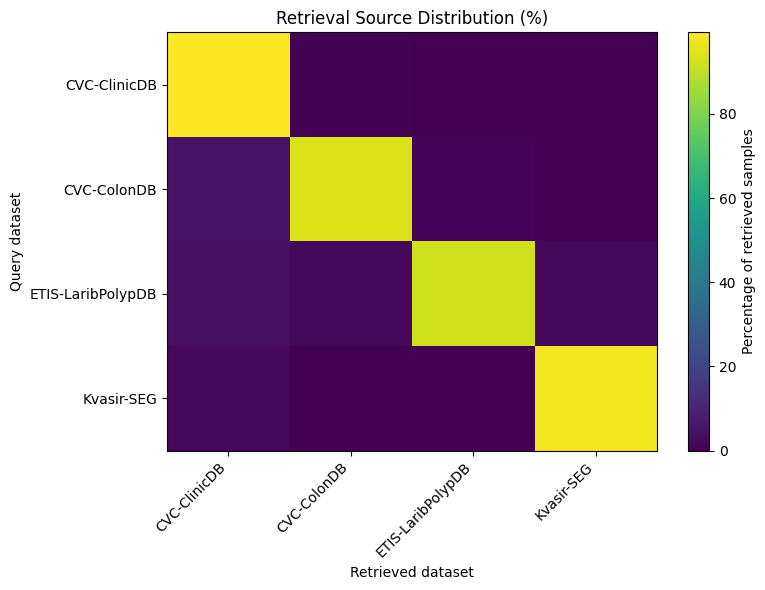

In [ ]:
heatmap_path = os.path.join(OUTPUT_DIR, "protocol_A_global_index", "retrieval_source_heatmap.png")
plot_source_matrix_heatmap(source_matrix_percent, save_path=heatmap_path)

In [ ]:
def show_results(query_path, results, figsize=(18, 4), save_path=None):
    """
    Displays:
    [Query | Top1 | Top2 | Top3 | Top4 | Top5]
    """

    ncols = len(results) + 1  # query + results
    plt.figure(figsize=figsize)

    # Query
    plt.subplot(1, ncols, 1)
    plt.imshow(open_rgb(query_path))
    plt.title("Query", fontsize=11)
    plt.axis("off")

    # Retrieved images
    for i, item in enumerate(results, start=2):
        plt.subplot(1, ncols, i)
        plt.imshow(open_rgb(item["image_path"]))
        plt.title(
            f"Top-{item['rank']}\n"
            f"{item['dataset']}\n"
            f"{item['similarity']:.3f}",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [ ]:
def make_one_example_per_dataset(
    protocol_out,
    model_id="google/medsiglip-448",
    top_k=5,
):
    index_df = protocol_out["index_df"]
    embeddings = np.load(protocol_out["embed_npy"])
    query_df = protocol_out["query_df"]

    device = "cuda" if torch.cuda.is_available() else "cpu"
    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(device).eval()

    for dataset_name in query_df["query_dataset"].unique():
        qsub = query_df[query_df["query_dataset"] == dataset_name].reset_index(drop=True)

        # deterministic, not cherry-picked: first test image in sorted order
        query_path = qsub.iloc[0]["query_image_path"]

        results = retrieve_similar_images_with_loaded_model(
            query_image_path=query_path,
            index_df=index_df,
            embeddings=embeddings,
            model=model,
            processor=processor,
            device=device,
            top_k=top_k,
        )

        print(f"\nDataset: {dataset_name}")
        print(f"Query: {query_path}")
        show_results(query_path, results, figsize=(16, 10))

    del model, processor
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]


Dataset: Kvasir-SEG
Query: /content/Datasets/Kvasir-SEG/test/images/0.jpg


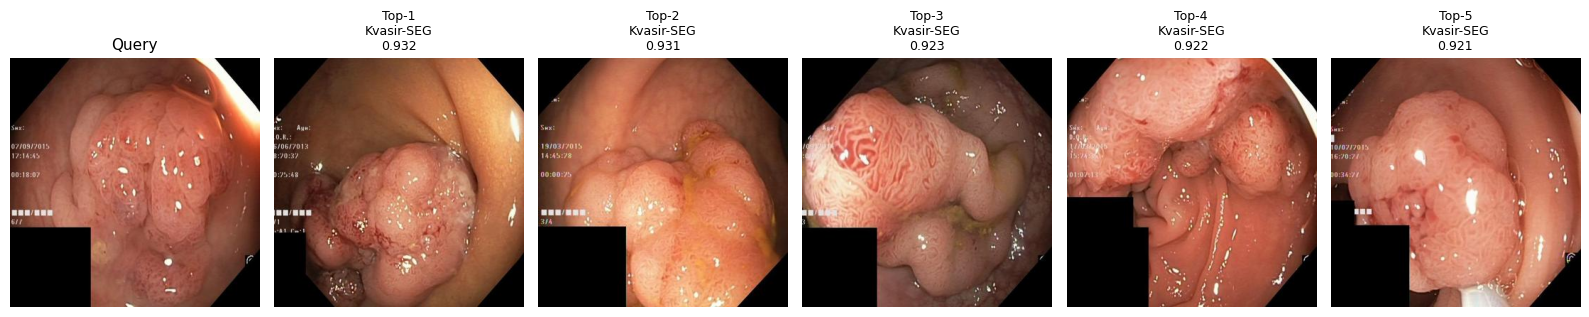


Dataset: CVC-ClinicDB
Query: /content/Datasets/CVC-ClinicDB/test/images/0.jpg


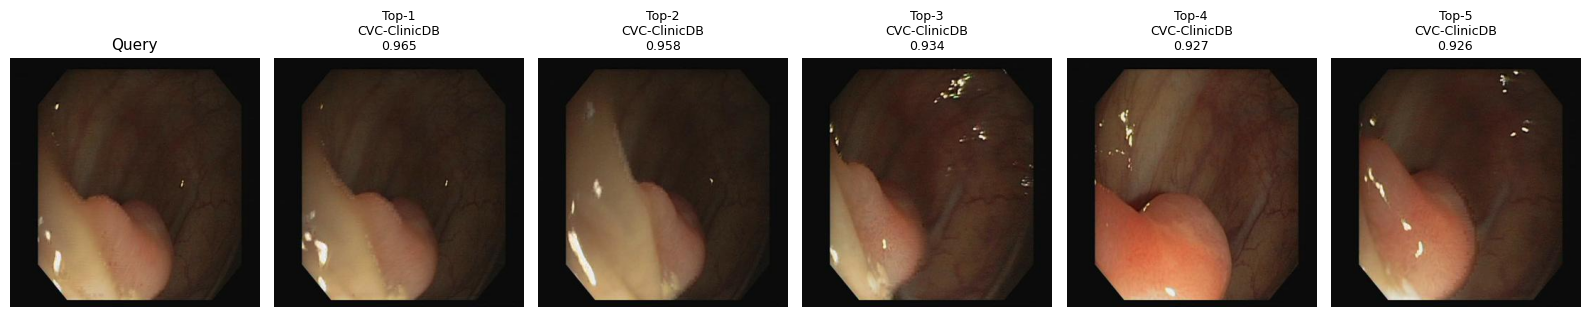


Dataset: CVC-ColonDB
Query: /content/Datasets/CVC-ColonDB/test/images/0.jpg


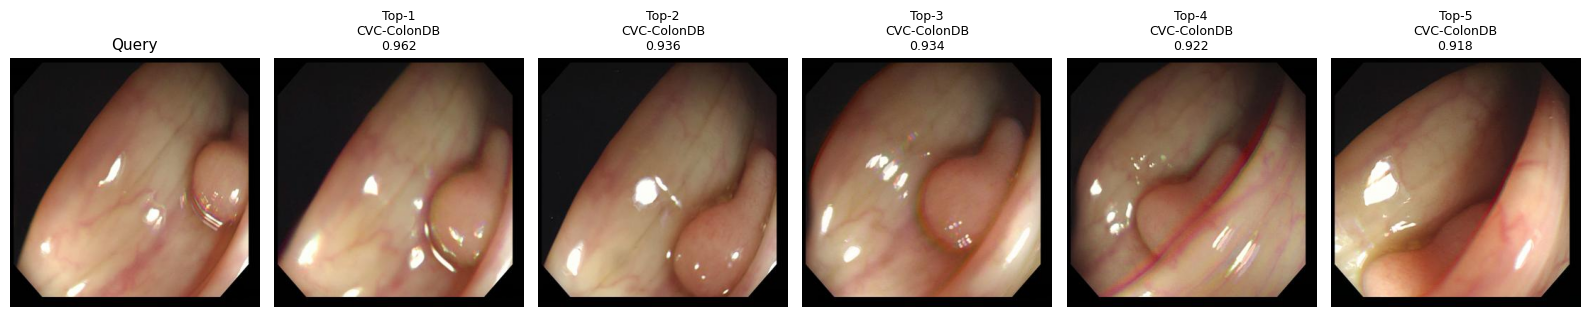


Dataset: ETIS-LaribPolypDB
Query: /content/Datasets/ETIS-LaribPolypDB/test/images/0.jpg


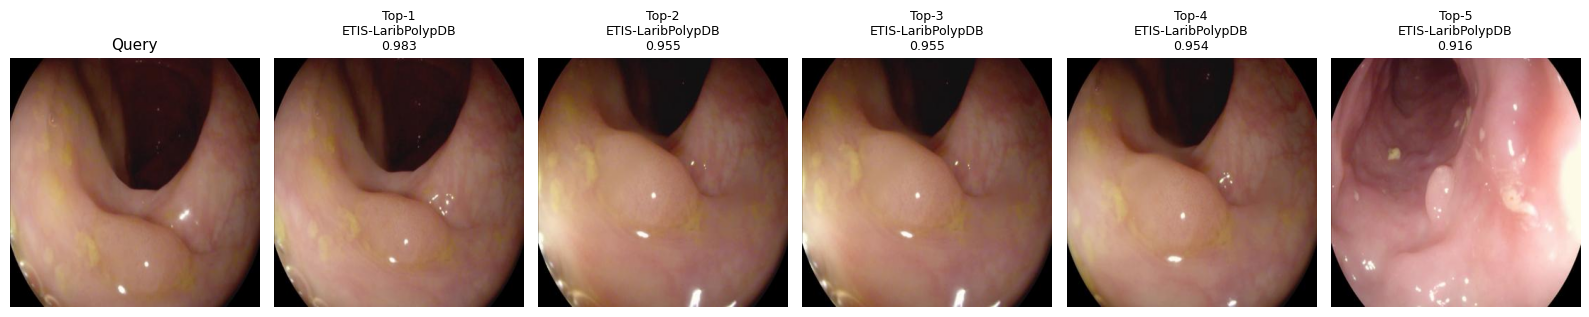

In [ ]:
make_one_example_per_dataset(
    protocol_a_out,
    model_id=RETRIEVAL_MODEL_ID,
    top_k=5,
)